In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy
from statsmodels.graphics.tsaplots import plot_acf, acf
from matplotlib.ticker import PercentFormatter
from scipy.integrate import quad
from math import cos, sqrt
import pandas as pd
import yaml
import os
SEED = 49
random.seed(SEED)
np.random.seed(SEED)
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/data/"

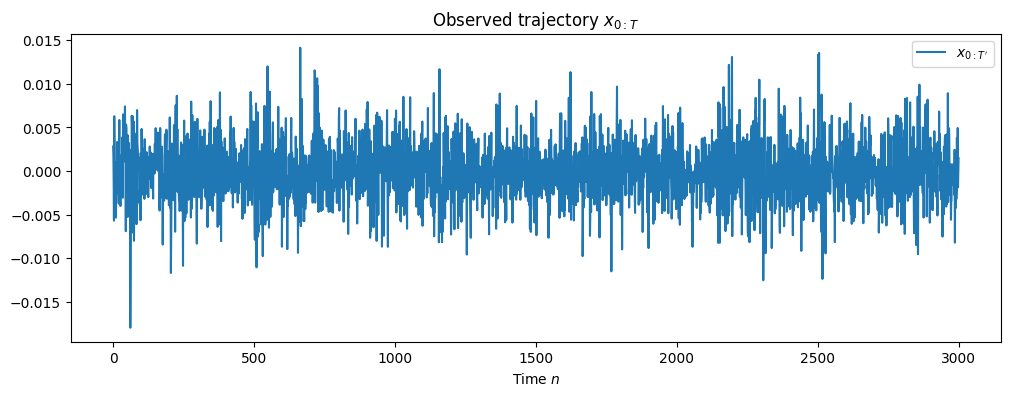

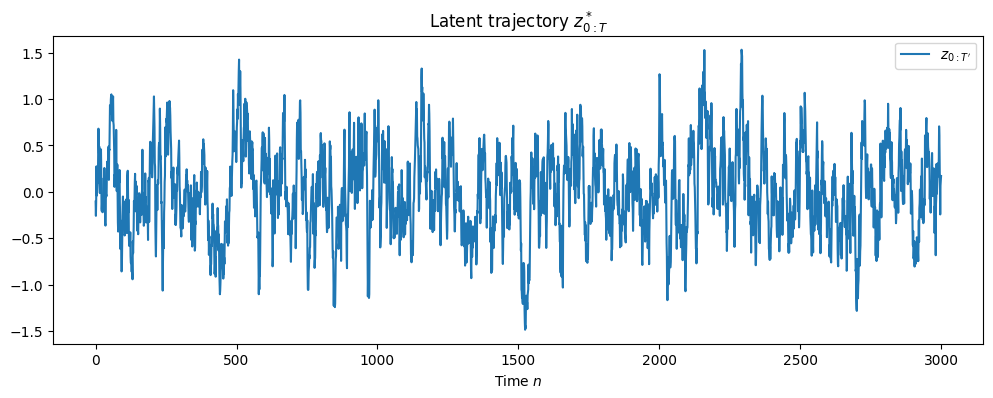

In [3]:
T = 3000
initial_distribution_variance = 0.01
sigma_true = 0.2
sigma2_true = sigma_true**2
rho_true = 0.9
beta_true = sqrt(1e-5)
beta2_true = beta_true**2

def generate_z(T):
    zs = []
    for k in range(T+1):
        # Compute z_k
        if k==0:
            z = scipy.stats.norm.rvs(loc=0, scale=sqrt(initial_distribution_variance))
        else:
            z = scipy.stats.norm.rvs(loc=rho_true * zs[k-1], scale=sigma_true)
        # Append state to trajectory
        zs.append(z)
    return np.array(zs)

def generate_x(zs):
    xs = []
    for zk in zs:
        xk = scipy.stats.norm.rvs(loc=0, scale=beta_true * np.exp(zk/2))
        xs.append(xk)
    return xs

z = generate_z(T)
x = generate_x(z)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(x, label=r"$x_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"Observed trajectory $x_{0:T}$")
plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(z, label=r"$z_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"Latent trajectory $z^*_{0:T}$")
plt.show()

In [3]:
# Find next ID
i = 0
while os.path.exists(results_path + f"/trajectory{i}.yaml"):
    i += 1

In [4]:
config = {"length": T,
          "initial_distribution_variance": initial_distribution_variance,
          "sigma_true": sigma_true,
          "sigma2_true": sigma2_true,
          "rho_true": rho_true,
          "beta_true": beta_true,
          "beta2_true": beta2_true}

trajectory = {"z": z,
              "x": x}

In [5]:
trajectory_path = results_path + f"trajectory{i}.npz"
config_path = results_path + f"trajectory{i}.yaml"

np.savez(trajectory_path, **trajectory)

with open(config_path, "w") as f:
    yaml.dump(config, f)